## Dataset REVIEWS
[Kaggle Link](https://www.kaggle.com/competitions/184-702-tu-ml-2025-w-reviews/overview)

### Imports

todo in code: remove ifs i did while debugging, clean code, document ig? -> create the docs

In [16]:
#!pip install openpyxl
import os
import sys
import pandas as pd

# Add the parent directory to sys.path to be able to import own packages from outside the notebooks directory
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# some helper functions (see src directory for details)
from src.utils import *
from src.evaluation import *


In [17]:
# Load the data and catch a quick glimpse.
curr_dir = os.getcwd()

# Load the given training and test data sets
train_path = os.path.join(curr_dir, '..', 'data', 'reviews/amazon_review_ID.shuf.lrn.csv')
#test_path = os.path.join(curr_dir, '..', 'data', 'reviews/amazon_review_ID.shuf.tes.csv')

train_df = pd.read_csv(train_path)
#final_test_df = pd.read_csv(test_path)

train_df.shape#, test_df.shape

(750, 10002)

In [18]:
train_df.describe()
# early cols have higher numerical values, later cols smaller values
train_df.info()
# each col is float64 except the last one which is object (the label)
# 750 rows, 100002 cols
# no missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Columns: 10002 entries, ID to Class
dtypes: int64(10001), object(1)
memory usage: 57.2+ MB


In [19]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Columns: 10002 entries, ID to Class
dtypes: int64(10001), object(1)
memory usage: 57.2+ MB


In [20]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, chi2, SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.cross_decomposition import PLSRegression

In [21]:
target_column = 'Class'
X, y = train_df.drop(columns=[target_column]), train_df[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
kfold_cv = KFold(n_splits=10, shuffle=True, random_state=42)

TODO FOR DOCS:

- each classifier show multiple results, not just the best  - show results with different  hyper param in each category, do 2-3 runs with best in A, the 3 random in B etc...
- evaluate the performance
    - here use the best modell
    - compare the 4 measures (acc recall prec ..)
    - how can i improve the results? feature selection, some kinda better scaluing?
    - which algo works well for the given dataset, why?
    - Compare holdout to cross-validation, maybe try different train/split sizes
    - run time
- create some kinda table/figure whith all the data collected


KNN

Fast, not much 'learning'

Feature Selection:

SelectKBest preffered, feature selection based on statisctical tests

Pros: Extremely Fast

Cons: It tests each feature in isolation.



--- Starting KNN Search (with scaler choices) ---
Fitting 10 folds for each of 40 candidates, totalling 400 fits
KNN search complete.

--- Best KNN Model (all params) ---
Best Score (CV Accuracy): 0.4583
Best Parameters:
{'knn__n_neighbors': 7, 'scaler': StandardScaler(), 'selector__k': 200}

Best CV accuracy per scaler:
      scaler_name  mean_test_score
0  StandardScaler         0.458333
1     passthrough         0.208333


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [2344 2916 3112 3293] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


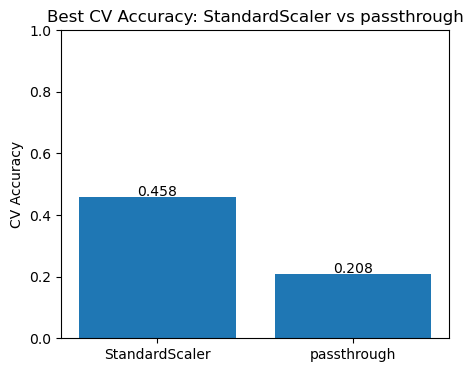

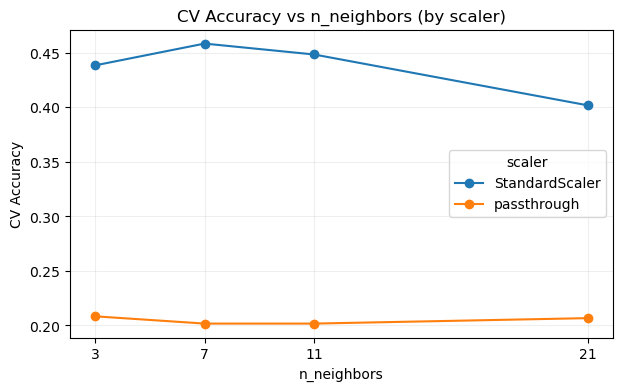

c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


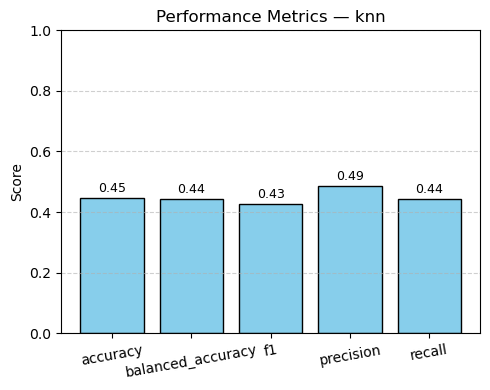

              precision    recall  f1-score   support

     Agresti       0.00      0.00      0.00         3
   Ashbacher       0.50      0.50      0.50         2
       Auken       1.00      0.50      0.67         2
 Blankenship       0.75      1.00      0.86         3
       Brody       0.22      0.67      0.33         3
       Brown       0.25      0.33      0.29         3
    Bukowsky       0.12      0.33      0.18         3
         CFH       1.00      0.67      0.80         3
   Calvinnme       1.00      1.00      1.00         3
     Chachra       0.25      1.00      0.40         4
    Chandler       0.00      0.00      0.00         3
       Chell       0.00      0.00      0.00         4
    Cholette       0.33      0.33      0.33         3
      Comdet       0.50      0.50      0.50         4
        Corn       0.20      0.33      0.25         3
       Cutey       0.00      0.00      0.00         3
    Davisson       0.25      0.50      0.33         4
        Dent       0.67    

c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [22]:
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()), # will be overridden by param_grid with 'passthrough'
    ('selector', SelectKBest(f_classif)),
    ('knn', KNeighborsClassifier())
])


param_grid_knn = {
    'scaler': [StandardScaler(), 'passthrough'],   # compare scaling vs no scaling
    'selector__k': [50, 100, 200, 300, 400],
    'knn__n_neighbors': [3, 7, 11, 21]
}

print("\n--- Starting KNN Search (with scaler choices) ---")
grid_knn = GridSearchCV(pipeline_knn, param_grid_knn, cv=kfold_cv,
                        scoring='accuracy', n_jobs=-1, verbose=1, return_train_score=False)
grid_knn.fit(X_train, y_train)
print("KNN search complete.\n")

# print best overall
print("--- Best KNN Model (all params) ---")
print(f"Best Score (CV Accuracy): {grid_knn.best_score_:.4f}")
print("Best Parameters:")
print(grid_knn.best_params_)

# === extract cv results into a DataFrame for analysis ===
cv = pd.DataFrame(grid_knn.cv_results_)

# helper to normalize scaler name (estimator objects => class name; 'passthrough' left as-is)
def scaler_name(x):
    if isinstance(x, str):
        return x
    try:
        return x.__class__.__name__
    except Exception:
        return str(x)

cv['scaler_name'] = cv['param_scaler'].apply(scaler_name)
cv['n_neighbors'] = cv['param_knn__n_neighbors'].astype(int)
cv['selector__k'] = cv['param_selector__k'].astype(int)

# 1) Best (max) CV accuracy achieved for each scaler (across other hyperparams)
best_per_scaler = cv.groupby('scaler_name')['mean_test_score'].max().reset_index()
print("\nBest CV accuracy per scaler:")
print(best_per_scaler)

# 2) A cleaner comparison: best accuracy per scaler (bar plot)
plt.figure(figsize=(5,4))
plt.bar(best_per_scaler['scaler_name'], best_per_scaler['mean_test_score'])
plt.ylim(0,1)
plt.ylabel('CV Accuracy')
plt.title('Best CV Accuracy: StandardScaler vs passthrough')
for i, v in enumerate(best_per_scaler['mean_test_score']):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')
plt.show()

# 3) More detailed: how mean CV accuracy varies with n_neighbors for each scaler
agg = cv.groupby(['scaler_name', 'n_neighbors'])['mean_test_score'].max().unstack('scaler_name')

plt.figure(figsize=(7,4))
for col in agg.columns:
    plt.plot(agg.index, agg[col], marker='o', label=col)
plt.xticks(agg.index)
plt.xlabel('n_neighbors')
plt.ylabel('CV Accuracy')
plt.title('CV Accuracy vs n_neighbors (by scaler)')
plt.legend(title='scaler')
plt.grid(alpha=0.2)
plt.show()

# === final test-evaluation using the overall best estimator ===
best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test)

evaluation = evaluate_run(name='knn', y_true=y_test, y_pred=y_pred_knn, task_type='classification')
plot_metrics(evaluation, figsize=(5,4), x_rotation=10)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_knn))


In [23]:
results_df_knn = pd.DataFrame(grid_knn.cv_results_)

print(results_df_knn)
print(f"\nTotal combinations tested: {len(results_df_knn)}")

    mean_fit_time  std_fit_time  ...  std_test_score  rank_test_score
0        0.563586      0.041388  ...        0.038730               16
1        0.541927      0.071432  ...        0.044597                5
2        0.515324      0.043625  ...        0.061033                4
3        0.502404      0.060518  ...        0.082597                9
4        0.529051      0.048457  ...        0.075351               13
5        0.284043      0.027710  ...        0.043589               26
6        0.253921      0.037556  ...        0.040995               21
7        0.251592      0.024656  ...        0.047170               29
8        0.244757      0.038086  ...        0.058238               31
9        0.258568      0.035967  ...        0.050990               28
10       0.513477      0.075321  ...        0.042850                8
11       0.540176      0.051074  ...        0.046577                2
12       0.572580      0.087968  ...        0.070415                1
13       0.562558   

SVM

Feature selection

SelectKBest(f_classif) -> fast
selector_estimator = LinearSVC (l1, l2) -> too slow, didnt finish



--- Starting FINETUNED SVM Search (Linear + RBF) ---
Fitting 10 folds for each of 300 candidates, totalling 3000 fits


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [2344 2916 3112 3293] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



--- SVM Search Complete ---
Best SVM Score (CV Accuracy): 0.6250
Best SVM Parameters Found:
{'scaler': StandardScaler(), 'selector__k': 150, 'svm__C': 0.05, 'svm__kernel': 'linear'}

Best CV accuracy per scaler (overall):
      scaler_name  mean_test_score
0  StandardScaler            0.625
1     passthrough            0.445


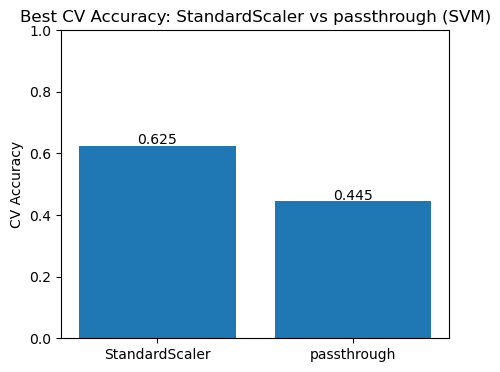

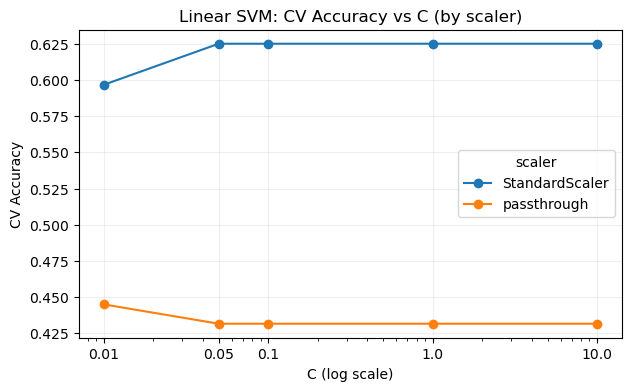


Linear kernel: best accuracy by (scaler, C):
scaler_name
StandardScaler    0.625
passthrough       0.445
dtype: float64


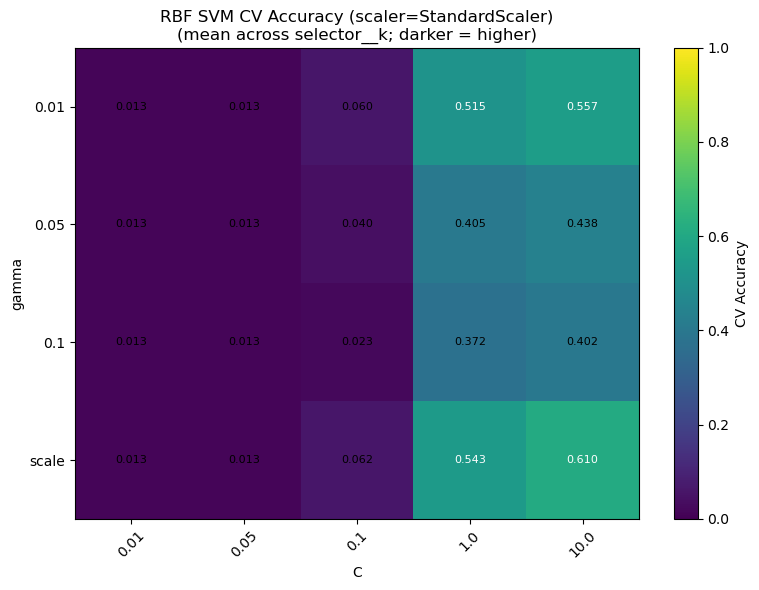

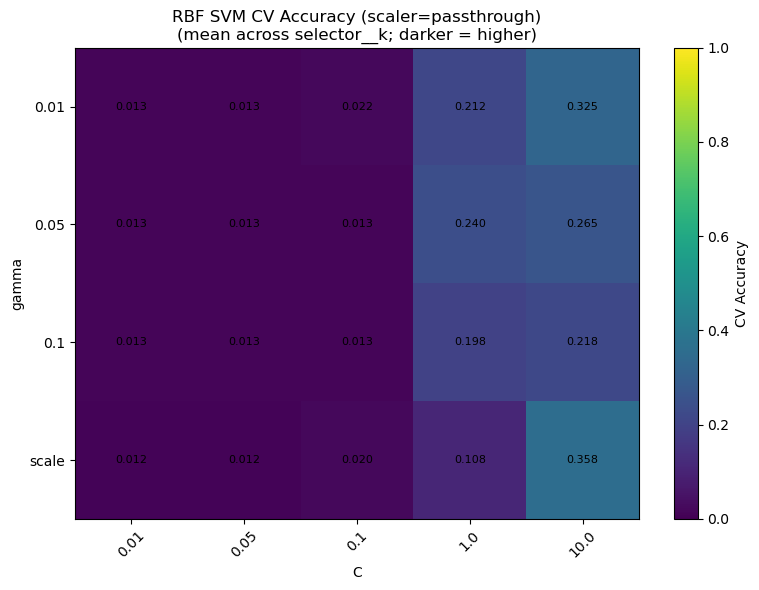


Top RBF configurations (scaler, gamma, C) by CV accuracy:
       scaler_name gamma_str     C  mean_test_score
19  StandardScaler     scale  10.0         0.610000
4   StandardScaler      0.01  10.0         0.556667
18  StandardScaler     scale   1.0         0.543333
3   StandardScaler      0.01   1.0         0.515000
9   StandardScaler      0.05  10.0         0.438333
8   StandardScaler      0.05   1.0         0.405000
14  StandardScaler       0.1  10.0         0.401667
13  StandardScaler       0.1   1.0         0.371667
39     passthrough     scale  10.0         0.358333
24     passthrough      0.01  10.0         0.325000

Best CV accuracy by kernel and scaler:
   kernel     scaler_name  mean_test_score
0  linear  StandardScaler         0.625000
2     rbf  StandardScaler         0.610000
1  linear     passthrough         0.445000
3     rbf     passthrough         0.358333


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


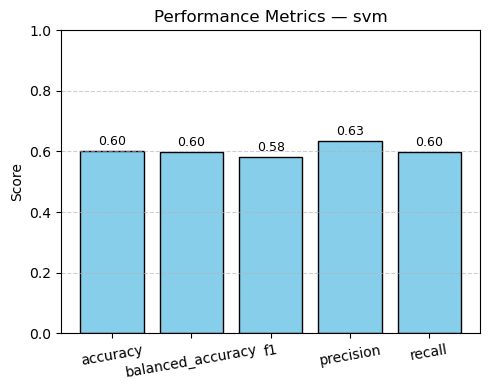


Classification report (test set) for best SVM:
              precision    recall  f1-score   support

     Agresti       0.67      0.67      0.67         3
   Ashbacher       1.00      0.50      0.67         2
       Auken       0.50      0.50      0.50         2
 Blankenship       1.00      1.00      1.00         3
       Brody       0.50      0.67      0.57         3
       Brown       0.33      0.67      0.44         3
    Bukowsky       0.33      0.33      0.33         3
         CFH       1.00      0.67      0.80         3
   Calvinnme       0.00      0.00      0.00         3
     Chachra       0.67      1.00      0.80         4
    Chandler       0.50      0.67      0.57         3
       Chell       0.20      0.25      0.22         4
    Cholette       0.50      0.67      0.57         3
      Comdet       0.50      0.50      0.50         4
        Corn       0.40      0.67      0.50         3
       Cutey       1.00      0.67      0.80         3
    Davisson       0.67      1.00

c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [24]:
# --- Algorithm 2: Support Vector Machine (SVM) ---
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(f_classif)), # f_classif acc: 0.60
    ('svm', SVC(probability=True, random_state=42)) 
])


# --- param grids (add scaler choice to both) ---
param_grid_linear = {
    'scaler': [StandardScaler(), 'passthrough'],
    'selector__k': [50, 100, 150, 170, 200, 500],
    'svm__kernel': ['linear'],
    'svm__C': [0.01, 0.05, 0.1, 1, 10]
}

param_grid_rbf = {
    'scaler': [StandardScaler(), 'passthrough'],
    'selector__k': [50, 100, 150, 170, 200, 500],
    'svm__kernel': ['rbf'],
    'svm__C': [0.01, 0.05, 0.1, 1, 10],
    'svm__gamma': ['scale', 0.01, 0.05, 0.1]
}

print("\n--- Starting FINETUNED SVM Search (Linear + RBF) ---")
# We pass the list of grids to the 'param_grid' argument
grid_svm = GridSearchCV(
    pipeline_svm,
    [param_grid_linear, param_grid_rbf],
    cv=kfold_cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)
grid_svm.fit(X_train, y_train)
print("\n--- SVM Search Complete ---")
print(f"Best SVM Score (CV Accuracy): {grid_svm.best_score_:.4f}")
print("Best SVM Parameters Found:")
print(grid_svm.best_params_)

# === extract cv results into DataFrame for plotting/analysis ===
cv = pd.DataFrame(grid_svm.cv_results_)

# helper: normalize scaler name
def scaler_name(x):
    if isinstance(x, str):
        return x
    try:
        return x.__class__.__name__
    except Exception:
        return str(x)

cv['scaler_name'] = cv['param_scaler'].apply(scaler_name)
cv['C'] = cv['param_svm__C'].astype(float)
# gamma can be 'scale' or numeric -> convert to string for pivoting/labels
cv['gamma_str'] = cv['param_svm__gamma'].astype(str)
cv['kernel'] = cv['param_svm__kernel'].astype(str)
cv['selector_k'] = cv['param_selector__k'].astype(int)
cv['mean_test_score'] = cv['mean_test_score'].astype(float)

# --- 1) Best CV accuracy per scaler (overall, across kernels and other params) ---
best_per_scaler = cv.groupby('scaler_name')['mean_test_score'].max().reset_index().sort_values('mean_test_score', ascending=False)
print("\nBest CV accuracy per scaler (overall):")
print(best_per_scaler)

# bar plot: best per scaler
plt.figure(figsize=(5,4))
plt.bar(best_per_scaler['scaler_name'], best_per_scaler['mean_test_score'])
plt.ylim(0,1)
plt.ylabel('CV Accuracy')
plt.title('Best CV Accuracy: StandardScaler vs passthrough (SVM)')
for i, v in enumerate(best_per_scaler['mean_test_score']):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')
plt.show()

# --- 2) Linear kernel: accuracy vs C (one line per scaler) ---
linear = cv[cv['kernel'] == 'linear'].copy()
if linear.shape[0] == 0:
    print("No linear-kernel runs found in cv results.")
else:
    # choose best mean_test_score across selector__k for each (scaler, C)
    agg_linear = linear.groupby(['scaler_name', 'C'])['mean_test_score'].max().unstack('scaler_name').sort_index()
    plt.figure(figsize=(7,4))
    for col in agg_linear.columns:
        plt.semilogx(agg_linear.index, agg_linear[col], marker='o', label=col)  # semilog for C
    plt.xlabel('C (log scale)')
    plt.ylabel('CV Accuracy')
    plt.title('Linear SVM: CV Accuracy vs C (by scaler)')
    plt.xticks(agg_linear.index, agg_linear.index)
    plt.grid(alpha=0.2)
    plt.legend(title='scaler')
    plt.show()
    print("\nLinear kernel: best accuracy by (scaler, C):")
    print(agg_linear.max().sort_values(ascending=False))

# --- 3) RBF kernel: heatmap(s) of accuracy by (gamma × C) for each scaler ---
rbf = cv[cv['kernel'] == 'rbf'].copy()
if rbf.shape[0] == 0:
    print("No RBF-kernel runs found in cv results.")
else:
    scalers = rbf['scaler_name'].unique()
    # create one heatmap per scaler
    for sc in scalers:
        df = rbf[rbf['scaler_name'] == sc]
        # pivot table: rows = gamma_str, cols = C
        pivot = df.groupby(['gamma_str', 'C'])['mean_test_score'].max().unstack(level=1)
        # sort columns by numeric C order
        pivot = pivot.reindex(columns=sorted(pivot.columns))
        # convert pivot to numpy matrix for imshow
        mat = pivot.values
        plt.figure(figsize=(8, 4 + 0.5 * len(pivot)))
        im = plt.imshow(mat, aspect='auto', vmin=0, vmax=1)
        plt.colorbar(im, label='CV Accuracy')
        plt.yticks(np.arange(len(pivot.index)), pivot.index)
        plt.xticks(np.arange(len(pivot.columns)), [str(c) for c in pivot.columns], rotation=45)
        plt.xlabel('C')
        plt.ylabel('gamma')
        plt.title(f'RBF SVM CV Accuracy (scaler={sc})\n(mean across selector__k; darker = higher)')
        # annotate numbers
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = mat[i, j]
                if not np.isnan(val):
                    plt.text(j, i, f"{val:.3f}", ha='center', va='center', fontsize=8, color='white' if val > 0.5 else 'black')
        plt.tight_layout()
        plt.show()

    # summary: best per (scaler, gamma, C)
    best_rbf = rbf.groupby(['scaler_name', 'gamma_str', 'C'])['mean_test_score'].max().reset_index()
    best_rbf_sorted = best_rbf.sort_values('mean_test_score', ascending=False).head(10)
    print("\nTop RBF configurations (scaler, gamma, C) by CV accuracy:")
    print(best_rbf_sorted)

# --- 4) summary by kernel + scaler ---
best_by_kernel_scaler = cv.groupby(['kernel', 'scaler_name'])['mean_test_score'].max().reset_index().sort_values('mean_test_score', ascending=False)
print("\nBest CV accuracy by kernel and scaler:")
print(best_by_kernel_scaler)

# === final test-evaluation using the overall best estimator ===
best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test)

evaluation = evaluate_run(name='svm', y_true=y_test, y_pred=y_pred_svm, task_type='classification')
plot_metrics(evaluation, figsize=(5,4), x_rotation=10)

print("\nClassification report (test set) for best SVM:")
print(classification_report(y_test, y_pred_svm))

In [25]:

# selector_estimator = LinearSVC(penalty='l2', C=0.1, dual=False, random_state=42, max_iter=2000)
#  # as an experiment i let it run for 95 mins, no result -> this might be good/precise but it takes too long
#  # even with SelectFromModel+l2 it takes a long time
# pipeline_svm_sfm = Pipeline([
#     ('scaler', StandardScaler()),
#     ('selector', SelectFromModel(selector_estimator)),
#     ('svm', LinearSVC(dual=False, random_state=42, max_iter=2000))
# ])


# param_grid_sfm = {
#     'selector__estimator__C': [0.01, 0.1, 1.0], # Tunes the selector's 'C'
#     'selector__threshold': ['mean', '1.25*mean', 'median'], # Tunes the cutoff
#     'svm__C': [0.01, 0.05, 0.1] # Tunes the final classifier's 'C'
# }

# print("\n--- Starting SVM Search (Strategy: SelectFromModel) ---")
# grid_svm_sfm = RandomizedSearchCV(  # option for a 'good enough' result: RandomizedSearchCV
#     pipeline_svm_sfm,
#     param_grid_sfm,
#     n_iter=10,
#     cv=kfold_cv,
#     scoring='accuracy',
#     n_jobs=-1,
#     verbose=1
# )
# grid_svm_sfm.fit(X_train, y_train)

# # -----------------------------------------------------------------
# # 5. Review and Evaluate
# # -----------------------------------------------------------------
# print("\n--- SVM (SelectFromModel) Search Complete ---")
# print(f"Best SVM Score (CV Accuracy): {grid_svm_sfm.best_score_:.4f}")
# print("Best SVM Parameters Found:")
# print(grid_svm_sfm.best_params_)

# best_svm_model = grid_svm_sfm.best_estimator_
# y_pred_svm = best_svm_model.predict(X_test)
# acc_svm = accuracy_score(y_test, y_pred_svm)

# print(f"\nFinal SVM Test Accuracy: {acc_svm:.4f}")
# print(classification_report(y_test, y_pred_svm))

wanted to do Recursive Feature Elimination, but realized that would take forever in case of 10k features -> check if there is threshold setting for this

# Decision Tree

not good for many features low sample size -> overfit on high dimensional data

Fitting 10 folds for each of 480 candidates, totalling 4800 fits

--- Best Decision Tree Model (overall) ---
Best Score (CV Accuracy): 0.3983
Best Parameters:
{'dt__criterion': 'gini', 'dt__max_depth': None, 'dt__min_samples_leaf': 5, 'scaler': StandardScaler(), 'selector__k': 150}

Best CV accuracy per scaler (overall):
      scaler_name  mean_test_score
0  StandardScaler         0.398333
1     passthrough         0.391667


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [2344 2916 3112 3293] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


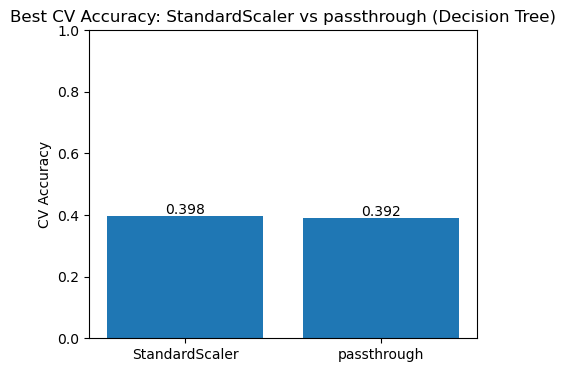

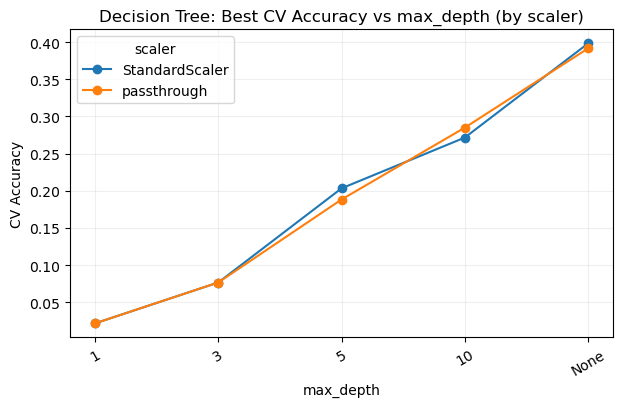


Best accuracy by (scaler, max_depth):
      scaler_name max_depth_str  max_depth_sort  mean_test_score
4  StandardScaler          None             inf         0.398333
9     passthrough          None             inf         0.391667
6     passthrough            10            10.0         0.285000
1  StandardScaler            10            10.0         0.271667
3  StandardScaler             5             5.0         0.203333
8     passthrough             5             5.0         0.188333
2  StandardScaler             3             3.0         0.076667
7     passthrough             3             3.0         0.076667
0  StandardScaler             1             1.0         0.021667
5     passthrough             1             1.0         0.021667


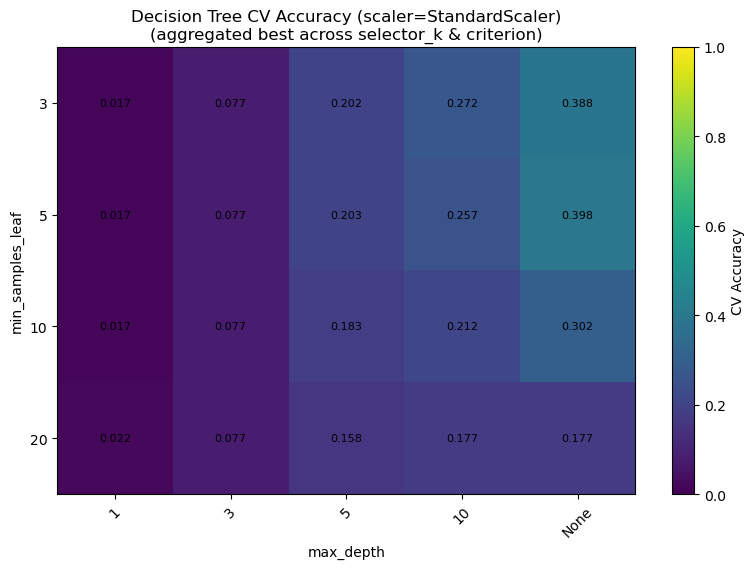

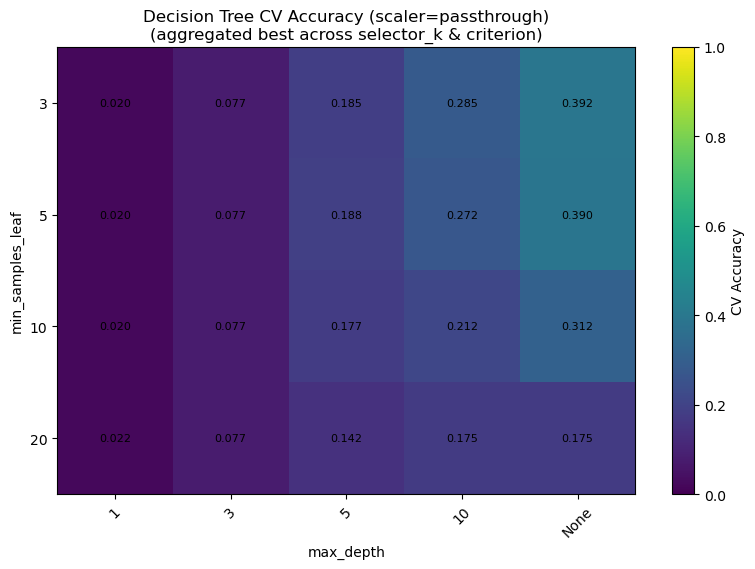


Best CV accuracy by (criterion, scaler):
  criterion     scaler_name  mean_test_score
2      gini  StandardScaler         0.398333
3      gini     passthrough         0.391667
1   entropy     passthrough         0.285000
0   entropy  StandardScaler         0.271667

DT Test Accuracy:  0.3467


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


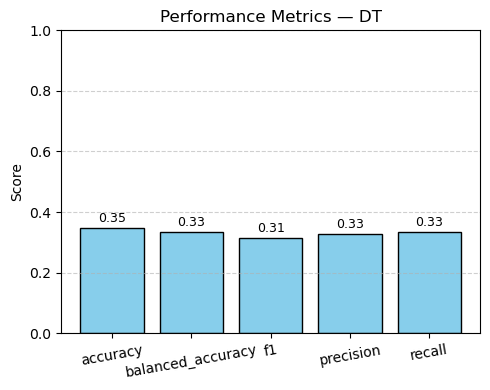


Classification report (test set) for best Decision Tree:
              precision    recall  f1-score   support

     Agresti       0.00      0.00      0.00         3
   Ashbacher       0.00      0.00      0.00         2
       Auken       0.00      0.00      0.00         2
 Blankenship       1.00      1.00      1.00         3
       Brody       0.00      0.00      0.00         3
       Brown       0.00      0.00      0.00         3
    Bukowsky       0.00      0.00      0.00         3
         CFH       0.14      0.33      0.20         3
   Calvinnme       0.00      0.00      0.00         3
     Chachra       0.60      0.75      0.67         4
    Chandler       1.00      0.33      0.50         3
       Chell       0.50      0.75      0.60         4
    Cholette       0.00      0.00      0.00         3
      Comdet       0.00      0.00      0.00         4
        Corn       0.00      0.00      0.00         3
       Cutey       0.00      0.00      0.00         3
    Davisson       0.20

c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [ ]:
pipeline_dt = Pipeline([
    ('scaler', 'passthrough'),
    ('selector', SelectKBest(f_classif)),
    ('dt', DecisionTreeClassifier(random_state=42))
])
param_grid_dt = {
    'scaler': [StandardScaler(), 'passthrough'],
    'selector__k': [50, 75, 100, 125, 150, 200],
    'dt__max_depth': [1, 3, 5, 10, None],
    'dt__criterion': ['gini', 'entropy'],
    'dt__min_samples_leaf': [3, 5, 10, 20]
}
grid_dt = GridSearchCV(pipeline_dt, param_grid_dt, cv=kfold_cv,
                        scoring='accuracy', n_jobs=-1, verbose=1, return_train_score=False)
grid_dt.fit(X_train, y_train)
# Print best overall
print("\n--- Best Decision Tree Model (overall) ---")
print(f"Best Score (CV Accuracy): {grid_dt.best_score_:.4f}")
print("Best Parameters:")
print(grid_dt.best_params_)

# === extract cv results into DataFrame ===
cv = pd.DataFrame(grid_dt.cv_results_)

# helper: normalize scaler name
def scaler_name(x):
    if isinstance(x, str):
        return x
    try:
        return x.__class__.__name__
    except Exception:
        return str(x)

cv['scaler_name'] = cv['param_scaler'].apply(scaler_name)

# Convert max_depth to a string label so None is preserved as 'None'
def max_depth_label(md):
    if pd.isna(md):
        return 'None'
    return str(md)

cv['max_depth_str'] = cv['param_dt__max_depth'].apply(max_depth_label)
# numeric form for sorting where possible (None -> np.inf)
def max_depth_sortval(md):
    if pd.isna(md):
        return np.inf
    return float(md)

cv['max_depth_sort'] = cv['param_dt__max_depth'].apply(max_depth_sortval)
cv['min_samples_leaf'] = cv['param_dt__min_samples_leaf'].astype(int)
cv['criterion'] = cv['param_dt__criterion'].astype(str)
cv['selector_k'] = cv['param_selector__k'].astype(int)
cv['mean_test_score'] = cv['mean_test_score'].astype(float)

# --- 1) Best CV accuracy per scaler (overall) ---
best_per_scaler = cv.groupby('scaler_name')['mean_test_score'].max().reset_index().sort_values('mean_test_score', ascending=False)
print("\nBest CV accuracy per scaler (overall):")
print(best_per_scaler)

# bar plot: best per scaler
plt.figure(figsize=(5,4))
plt.bar(best_per_scaler['scaler_name'], best_per_scaler['mean_test_score'])
plt.ylim(0,1)
plt.ylabel('CV Accuracy')
plt.title('Best CV Accuracy: StandardScaler vs passthrough (Decision Tree)')
for i, v in enumerate(best_per_scaler['mean_test_score']):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')
plt.show()

# --- 2) Accuracy vs max_depth (one line per scaler) ---
# aggregate by taking the best mean_test_score across selector_k, criterion, min_samples_leaf for each (scaler, max_depth)
agg_depth = cv.groupby(['scaler_name', 'max_depth_str', 'max_depth_sort'])['mean_test_score'].max().reset_index()
# sort by numeric ordering using max_depth_sort
agg_depth = agg_depth.sort_values(['scaler_name', 'max_depth_sort'])
pivot_depth = agg_depth.pivot(index='max_depth_str', columns='scaler_name', values='mean_test_score').reindex(agg_depth['max_depth_str'].unique())

plt.figure(figsize=(7,4))
for col in pivot_depth.columns:
    plt.plot(pivot_depth.index, pivot_depth[col], marker='o', label=col)
plt.xlabel('max_depth')
plt.ylabel('CV Accuracy')
plt.title('Decision Tree: Best CV Accuracy vs max_depth (by scaler)')
plt.legend(title='scaler')
plt.grid(alpha=0.2)
plt.xticks(rotation=30)
plt.show()

print("\nBest accuracy by (scaler, max_depth):")
print(agg_depth.sort_values('mean_test_score', ascending=False).head(10))

# --- 3) Heatmaps of (min_samples_leaf × max_depth) for each scaler ---
# We'll aggregate across selector_k and criterion by taking the best mean_test_score for each (scaler, max_depth, min_samples_leaf)
agg_heat = cv.groupby(['scaler_name', 'max_depth_str', 'min_samples_leaf'])['mean_test_score'].max().reset_index()

scalers = agg_heat['scaler_name'].unique()
for sc in scalers:
    df = agg_heat[agg_heat['scaler_name'] == sc]
    pivot = df.pivot(index='min_samples_leaf', columns='max_depth_str', values='mean_test_score')
    # reorder columns by numeric max_depth where possible (place 'None' at the end)
    # build order from agg_depth unique ordering
    col_order = list(agg_depth[agg_depth['scaler_name'] == sc]['max_depth_str'].unique())
    # ensure pivot columns follow col_order intersection
    cols = [c for c in col_order if c in pivot.columns]
    pivot = pivot[cols]
    mat = pivot.values
    plt.figure(figsize=(8, 3 + 0.7 * pivot.shape[0]))
    im = plt.imshow(mat, aspect='auto', vmin=0, vmax=1)
    plt.colorbar(im, label='CV Accuracy')
    plt.yticks(np.arange(len(pivot.index)), pivot.index)
    plt.xticks(np.arange(len(pivot.columns)), pivot.columns, rotation=45)
    plt.xlabel('max_depth')
    plt.ylabel('min_samples_leaf')
    plt.title(f'Decision Tree CV Accuracy (scaler={sc})\n(aggregated best across selector_k & criterion)')
    # annotate
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat[i, j]
            if not np.isnan(val):
                plt.text(j, i, f"{val:.3f}", ha='center', va='center', fontsize=8, color='white' if val > 0.5 else 'black')
    plt.tight_layout()
    plt.show()

# --- 4) Best by criterion + scaler (helpful summary) ---
best_by_crit_scaler = cv.groupby(['criterion', 'scaler_name'])['mean_test_score'].max().reset_index().sort_values('mean_test_score', ascending=False)
print("\nBest CV accuracy by (criterion, scaler):")
print(best_by_crit_scaler)

# === final test evaluation using the overall best estimator ===
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"\nDT Test Accuracy:  {acc_dt:.4f}")

evaluation = evaluate_run(name='DT', y_true=y_test, y_pred=y_pred_dt, task_type='classification')
plot_metrics(evaluation, figsize=(5,4), x_rotation=10)
print("\nClassification report (test set) for best Decision Tree:")
print(classification_report(y_test, y_pred_dt))

In [26]:
# Imports
# takes long, remove some of the hyperparams,
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# --- Build pipeline: selector is a placeholder to be replaced by SelectFromModel objects or 'passthrough' ---
pipeline_dt_sel = Pipeline([
    ('scaler', 'passthrough'),
    ('selector', 'passthrough'),   # will be replaced by SelectFromModel(...) in param grid
    ('dt', DecisionTreeClassifier(random_state=42))
])

# --- Instantiate the selector-wrapping estimators (they will be fit inside SelectFromModel)
# Note: keep n_estimators moderate to limit run time, increase if budget allows.
rf_for_sel = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
gb_for_sel = GradientBoostingClassifier(n_estimators=200, random_state=42)

# SelectFromModel objects (not prefit) — these will be fit as part of the pipeline
sfm_rf = SelectFromModel(estimator=rf_for_sel, threshold='median')   # selects features with importance >= median
sfm_gb = SelectFromModel(estimator=gb_for_sel, threshold='median')

# --- Param grid: try RF/GB selectors and passthrough, plus scaler choices and DT hyperparams ---
param_grid_sel = {
    'scaler': [StandardScaler(), 'passthrough'],
    'selector': [sfm_rf, sfm_gb, 'passthrough'],
    'dt__max_depth': [1, 3, 5, 10, None],
    'dt__criterion': ['gini', 'entropy'],
    'dt__min_samples_leaf': [3, 5, 10]
}

print("--- Starting Decision Tree Search with SelectFromModel(RF/GB) selectors ---")
grid_dt_selmodel = GridSearchCV(
    pipeline_dt_sel,
    param_grid_sel,
    cv=kfold_cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)
grid_dt_selmodel.fit(X_train, y_train)
print("Search complete.")

# Print best overall
print("\n--- Best Decision Tree (with embedded selectors) ---")
print(f"Best CV Score: {grid_dt_selmodel.best_score_:.4f}")
print("Best Params:")
print(grid_dt_selmodel.best_params_)

# === extract cv results into DataFrame ===
cv = pd.DataFrame(grid_dt_selmodel.cv_results_)

# helper to normalize selector name
def selector_name(x):
    if isinstance(x, str):
        return x
    try:
        # x is a SelectFromModel; return wrapped estimator class name
        return x.estimator.__class__.__name__ if hasattr(x, 'estimator') else x.__class__.__name__
    except Exception:
        return str(x)

cv['selector_name'] = cv['param_selector'].apply(selector_name)
cv['scaler_name'] = cv['param_scaler'].apply(lambda x: x.__class__.__name__ if not isinstance(x, str) else x)
cv['max_depth_str'] = cv['param_dt__max_depth'].apply(lambda md: 'None' if pd.isna(md) else str(md))
cv['min_samples_leaf'] = cv['param_dt__min_samples_leaf'].astype(int)
cv['criterion'] = cv['param_dt__criterion'].astype(str)
cv['mean_test_score'] = cv['mean_test_score'].astype(float)

# --- 1) Best CV accuracy per selector (overall) ---
best_per_selector = cv.groupby('selector_name')['mean_test_score'].max().reset_index().sort_values('mean_test_score', ascending=False)
print("\nBest CV accuracy per selector (overall):")
print(best_per_selector)

# bar plot: best per selector
plt.figure(figsize=(6,4))
plt.bar(best_per_selector['selector_name'], best_per_selector['mean_test_score'])
plt.ylim(0,1)
plt.ylabel('CV Accuracy')
plt.title('Best CV Accuracy: SelectFromModel(RF/GB) vs passthrough (Decision Tree)')
for i, v in enumerate(best_per_selector['mean_test_score']):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')
plt.show()

# --- 2) Accuracy vs max_depth (one line per selector) ---
agg_depth = cv.groupby(['selector_name', 'max_depth_str'])['mean_test_score'].max().unstack('selector_name')
plt.figure(figsize=(8,4))
for col in agg_depth.columns:
    plt.plot(agg_depth.index, agg_depth[col], marker='o', label=col)
plt.xlabel('max_depth')
plt.ylabel('CV Accuracy')
plt.title('Decision Tree: CV Accuracy vs max_depth (by selector)')
plt.legend(title='selector')
plt.grid(alpha=0.2)
plt.xticks(rotation=20)
plt.show()

print("\nTop (selector, max_depth) combos:")
print(cv.groupby(['selector_name', 'max_depth_str'])['mean_test_score'].max().reset_index().sort_values('mean_test_score', ascending=False).head(10))

# --- 3) Heatmaps: min_samples_leaf × max_depth per selector (aggregated across scaler & criterion by best score) ---
agg_heat = cv.groupby(['selector_name', 'max_depth_str', 'min_samples_leaf'])['mean_test_score'].max().reset_index()

selectors = agg_heat['selector_name'].unique()
for sel in selectors:
    df = agg_heat[agg_heat['selector_name'] == sel]
    if df.empty:
        continue
    pivot = df.pivot(index='min_samples_leaf', columns='max_depth_str', values='mean_test_score')
    # reorder columns so numeric order then 'None' at end if present
    cols_sorted = sorted([c for c in pivot.columns if c != 'None'], key=lambda x: float(x)) + (['None'] if 'None' in pivot.columns else [])
    pivot = pivot[cols_sorted]
    mat = pivot.values
    plt.figure(figsize=(8, 3 + 0.6*pivot.shape[0]))
    im = plt.imshow(mat, aspect='auto', vmin=0, vmax=1)
    plt.colorbar(im, label='CV Accuracy')
    plt.yticks(np.arange(len(pivot.index)), pivot.index)
    plt.xticks(np.arange(len(pivot.columns)), pivot.columns, rotation=45)
    plt.xlabel('max_depth')
    plt.ylabel('min_samples_leaf')
    plt.title(f'DT CV Accuracy (selector={sel})\n(aggregated best across scaler & criterion)')
    # annotate
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat[i, j]
            if not np.isnan(val):
                plt.text(j, i, f"{val:.3f}", ha='center', va='center', fontsize=8,
                         color='white' if val > 0.55 else 'black')
    plt.tight_layout()
    plt.show()

# === 4) Inspect which features were selected by the best pipeline (if selector is SelectFromModel) ===
best_pipe = grid_dt_selmodel.best_estimator_  # Pipeline object
best_selector = best_pipe.named_steps['selector']

if isinstance(best_selector, SelectFromModel):
    # get mask of selected features (works when selector has been fit)
    try:
        mask = best_selector.get_support()
        selected_idx = np.where(mask)[0]
        print(f"\nNumber of features selected by best selector: {len(selected_idx)}")
        # If X_train is a DataFrame with column names, prefer names:
        try:
            feature_names = X_train.columns
        except Exception:
            feature_names = [f'feat_{i}' for i in range(X_train.shape[1])]
        selected_features = [feature_names[i] for i in selected_idx]
        print("Top selected features (first 50 shown):", selected_features[:50])

        # For SelectFromModel with tree-based estimator we can show importances from the wrapped estimator:
        wrapped_est = best_selector.estimator_
        importances = None
        if hasattr(wrapped_est, 'feature_importances_'):
            # Note: wrapped_est is refit inside pipeline; if pipeline refits the wrapped estimator, this attribute exists
            try:
                importances = wrapped_est.feature_importances_
            except Exception:
                # sometimes the wrapped estimator stored under a different attribute after pipeline refit
                importances = getattr(wrapped_est, 'feature_importances_', None)

        if importances is not None:
            # restrict to selected features and plot sorted by importance
            sel_importances = importances[mask]
            order = np.argsort(sel_importances)[::-1]
            plt.figure(figsize=(8, max(3, 0.2*len(sel_importances))))
            plt.barh(np.array(selected_features)[order], sel_importances[order])
            plt.xlabel('Importance')
            plt.title('Feature importances (selected features)')
            plt.gca().invert_yaxis()
            plt.tight_layout()
            plt.show()
        else:
            print("Wrapped estimator does not expose feature_importances_ (or not available after refit).")
    except Exception as e:
        print("Could not extract selected features:", e)
else:
    print("\nBest selector is passthrough (no selection) — nothing to list.")

# === final evaluation of best pipeline on test set ===
best_dt_sel = grid_dt_selmodel.best_estimator_
y_pred_dt_sel = best_dt_sel.predict(X_test)
acc_dt_sel = accuracy_score(y_test, y_pred_dt_sel)
print(f"\nDT (with SelectFromModel selector) Test Accuracy: {acc_dt_sel:.4f}")
evaluation = evaluate_run(name='DT_sfm', y_true=y_test, y_pred=y_pred_dt_sel, task_type='classification')
plot_metrics(evaluation, figsize=(5,4), x_rotation=10)
print("\nClassification report (test set):")
print(classification_report(y_test, y_pred_dt_sel))


--- Starting Decision Tree Search with SelectFromModel(RF/GB) selectors ---
Fitting 10 folds for each of 180 candidates, totalling 1800 fits


KeyboardInterrupt: 